# Imports/Settings

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# 1. Стандартная библиотека
import os
import sys
import warnings
from pathlib import Path

# --- ДИНАМИЧЕСКИЙ РАСЧЕТ АБСОЛЮТНЫХ ПУТЕЙ ---
notebook_dir = Path(os.getcwd()).resolve()
if notebook_dir.name == "notebooks":
    PROJECT_ROOT = notebook_dir.parent
else:
    PROJECT_ROOT = notebook_dir

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# 2. Сторонние библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Локальные модули (Движок)
from src.core.data import DevDuckDBDataSource
from src.core.splitting import split_data
from src.core.pipeline import MLPipeline
from src.core.utils import load_hydra_config
from src.core.artifacts import ArtifactManager
from src.eda.visualisation import feature_importance


# --- РАБОТА С ПРЕДУПРЕЖДЕНИЯМИ ---
warnings.filterwarnings('ignore', category=FutureWarning)

# --- ИНИЦИАЛИЗАЦИЯ HYDRA ---
load_hydra_config.cache_clear()
cfg = load_hydra_config()


print(f"Проект: {cfg.project_name} | Режим: Baseline Modeling")

try:
    p_cfg = cfg.logging.plots
    plt.style.use(p_cfg.style)
    plt.rcParams.update({
        'figure.figsize': p_cfg.fig_size,
        'figure.dpi': p_cfg.dpi,
        'font.size': p_cfg.font_size,
        'axes.grid': p_cfg.grid,
        'axes.spines.top': p_cfg.spines_top,
        'axes.spines.right': p_cfg.spines_right
    })
    PLOT_ALPHA = p_cfg.alpha
except AttributeError:
    PLOT_ALPHA = 0.5
    print("Используются дефолтные стили Matplotlib.")

Проект: credit-risk-model | Режим: Baseline Modeling


# Data Loading

In [3]:
loader = DevDuckDBDataSource(cfg, PROJECT_ROOT)
df = loader.load()

# Наш метод get_splits сам разобьет данные согласно config.data.test_size
train_df, val_df, test_df = split_data(cfg, df)

target = cfg.data.tabular.target_col

X_train, y_train = train_df.drop(columns=[target]), train_df[target]
X_val, y_val = val_df.drop(columns=[target]), val_df[target]
X_test, y_test = test_df.drop(columns=[target]), test_df[target]

print(f"Обучающая выборка: {X_train.shape}")
print(f"Валидационная выборка: {X_val.shape}")
print(f"Тестовая выборка: {X_test.shape}")

Обучающая выборка: (277067, 61)
Валидационная выборка: (39276, 61)
Тестовая выборка: (79149, 61)


# Baselinge

In [4]:
# 1. Инициализируем наш ООП-менеджер артефактов
tracker = ArtifactManager(cfg, PROJECT_ROOT)

# 2. Достаем имя эксперимента для режима train
mode_for_exp = cfg.mode.lower() if cfg.mode else "train"
experiment_name = cfg.logging.mlflow.experiments.get(mode_for_exp, "default_experiment")

tracker.set_experiment(experiment_name, artifact_location=tracker.artifact_uri)

# 4. Берем динамический run_name прямо из конфига Hydra
run_name = cfg.run_name

In [5]:
# 5. Открываем сессию через контекстный менеджер нашего трекера
with tracker.start_run(run_name=cfg.run_name):
    print(f"Запуск MLflow Run: {cfg.run_name}")
    
    pipeline = MLPipeline(cfg=cfg, project_root=PROJECT_ROOT, tracker=tracker)
    model = pipeline.train(X_train, y_train, X_val, y_val, save_artifacts=True)
    
    print("Обучение завершено! База данных и артефакты успешно инициализированы.")

Запуск MLflow Run: p_v0.0.1__f_v0.0.0__m_v0.0.0
Learning rate set to 0.127124
0:	test: 0.6042026	best: 0.6042026 (0)	total: 1.04s	remaining: 17m 24s
50:	test: 0.6407772	best: 0.6408976 (48)	total: 38.5s	remaining: 11m 55s
100:	test: 0.6477929	best: 0.6480671 (96)	total: 1m 11s	remaining: 10m 37s
150:	test: 0.6600150	best: 0.6601338 (147)	total: 1m 55s	remaining: 10m 49s
200:	test: 0.6565255	best: 0.6606545 (158)	total: 2m 39s	remaining: 10m 35s
250:	test: 0.6536019	best: 0.6606545 (158)	total: 3m 23s	remaining: 10m 6s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6606544848
bestIteration = 158

Shrink model to first 159 iterations.
              precision    recall  f1-score   support

           0       0.98      0.72      0.83     38287
           1       0.04      0.48      0.08       989

    accuracy                           0.72     39276
   macro avg       0.51      0.60      0.46     39276
weighted avg       0.96      0.72      0.81     39276

{'accuracy

c:\credit-risk-model\.venv\lib\site-packages\omegaconf\grammar_visitor.py:253: UserWarning: In the sequence `API_ALLOWED_KEYS,` some elements are missing: please replace them with empty quoted strings. See https://github.com/omry/omegaconf/issues/572 for details.
  warnings.warn(


# Feature Importance

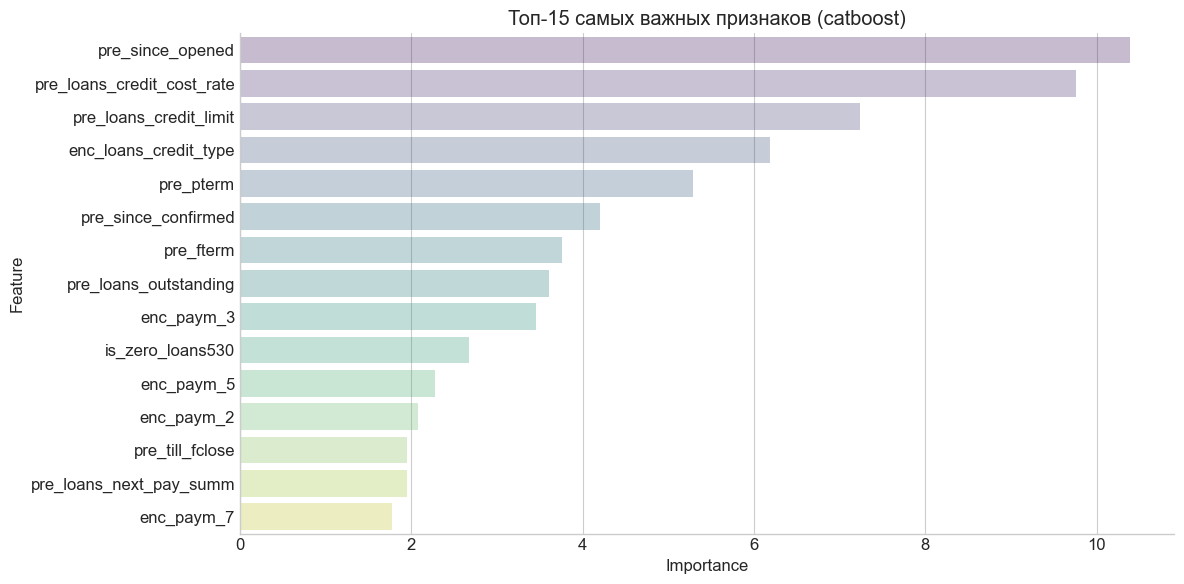

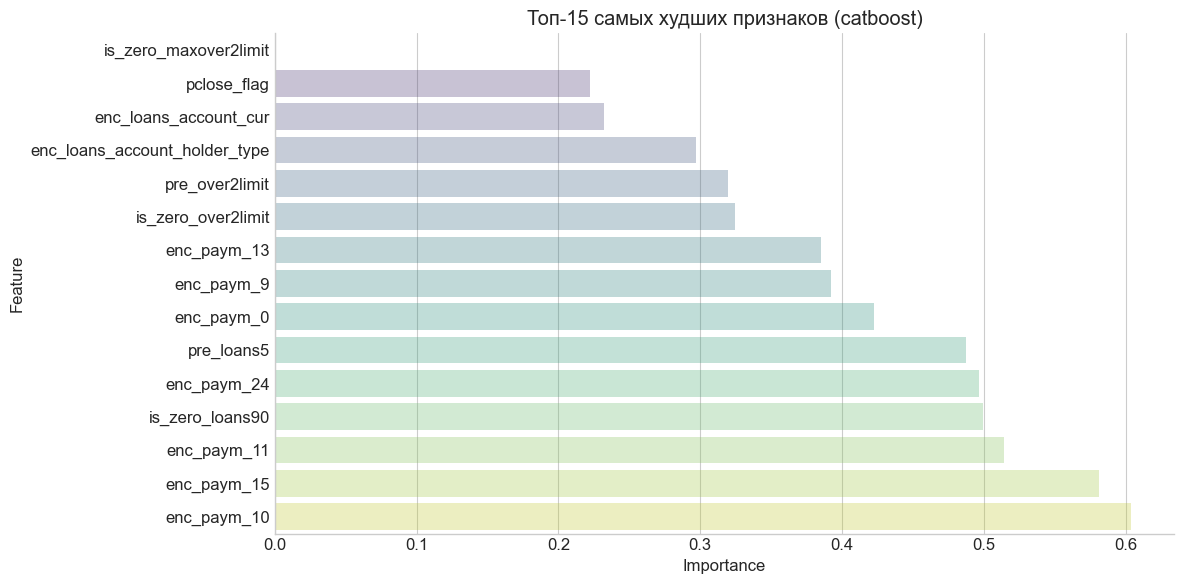

In [6]:
if hasattr(model.model, 'feature_importances_'):
    importances = model.model.feature_importances_
    
    # 1. Просто прогоняем тестовые признаки через предобработку
    X_test_clean = pipeline.preprocessor.transform(X_test)
    
    # 2. Имена колонок гарантированно лежат в самом чистом DataFrame!
    feature_names = X_test_clean.columns.tolist()

    fi_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    feature_importance(cfg=cfg, project_root=PROJECT_ROOT, fi_df=fi_df)
else:
    print("У выбранной модели нет встроенного атрибута feature_importances_.")

# Выводы по Feature Importance

- unique_event_actions - Огромный отрыв, логично что количество уникальных типов действий отражает глубину исследования сервиса. Пользватель который исопльзует много разных инструментов имеет другой паттерн поведения
- car_view_ratio и total_car_views -если пользователь сосредоточен на машинах а не ползает по всему сайту то конверсия возрастает
- visit_number прогрев клиента, чем больше раз заходил тем выше конверсия
- screen_area - возможно влияет адаптированность интерфейса под экран 

# Выводы по худшим фичам

- geo_country вероятно потому что большая часть всех запросов из России, поэтому этот параметр одинаково влияет как на таргет так и на пустые действия
- geo_zone как производная от geo_country
- is_weekend неожиданно но день недели не влияет на конверсию
- is_first_hit_car_view еще более неожиданно но то откуда пришел клиент по машине или на другую страницу также не сильно влияет на конверсию